# 08 - XGBoost

Train and evaluate `XGBClassifier` on the lung cancer dataset.
- Hyperparameter tuning (learning_rate, max_depth, n_estimators, scale_pos_weight)
- Feature importance analysis
- Confusion matrix, classification report

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, classification_report, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load processed data
PROCESSED = Path('..') / 'data' / 'processed'
X_train = pd.read_csv(PROCESSED / 'X_train.csv').astype(float)
X_test = pd.read_csv(PROCESSED / 'X_test.csv').astype(float)
y_train = pd.read_csv(PROCESSED / 'y_train.csv').values.ravel().astype(int)
y_test = pd.read_csv(PROCESSED / 'y_test.csv').values.ravel().astype(int)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (447, 15), Test: (112, 15)


In [4]:
# Compute scale_pos_weight for imbalanced dataset
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}")

# Hyperparameter tuning
# Using scoring='f1' because the dataset is highly imbalanced (87% YES vs 13% NO)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [1, spw],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

scale_pos_weight = 0.15
Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 1.0}
Best CV F1: 0.9746


In [5]:
# Evaluate on test set
best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print("=== XGBoost - Test Results ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"MCC:       {mcc:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

=== XGBoost - Test Results ===
Accuracy:  0.9732
Precision: 0.9798
Recall:    0.9898
F1-Score:  0.9848
AUC-ROC:   0.9789
MCC:       0.8745

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.98      0.99      0.98        98

    accuracy                           0.97       112
   macro avg       0.95      0.92      0.94       112
weighted avg       0.97      0.97      0.97       112



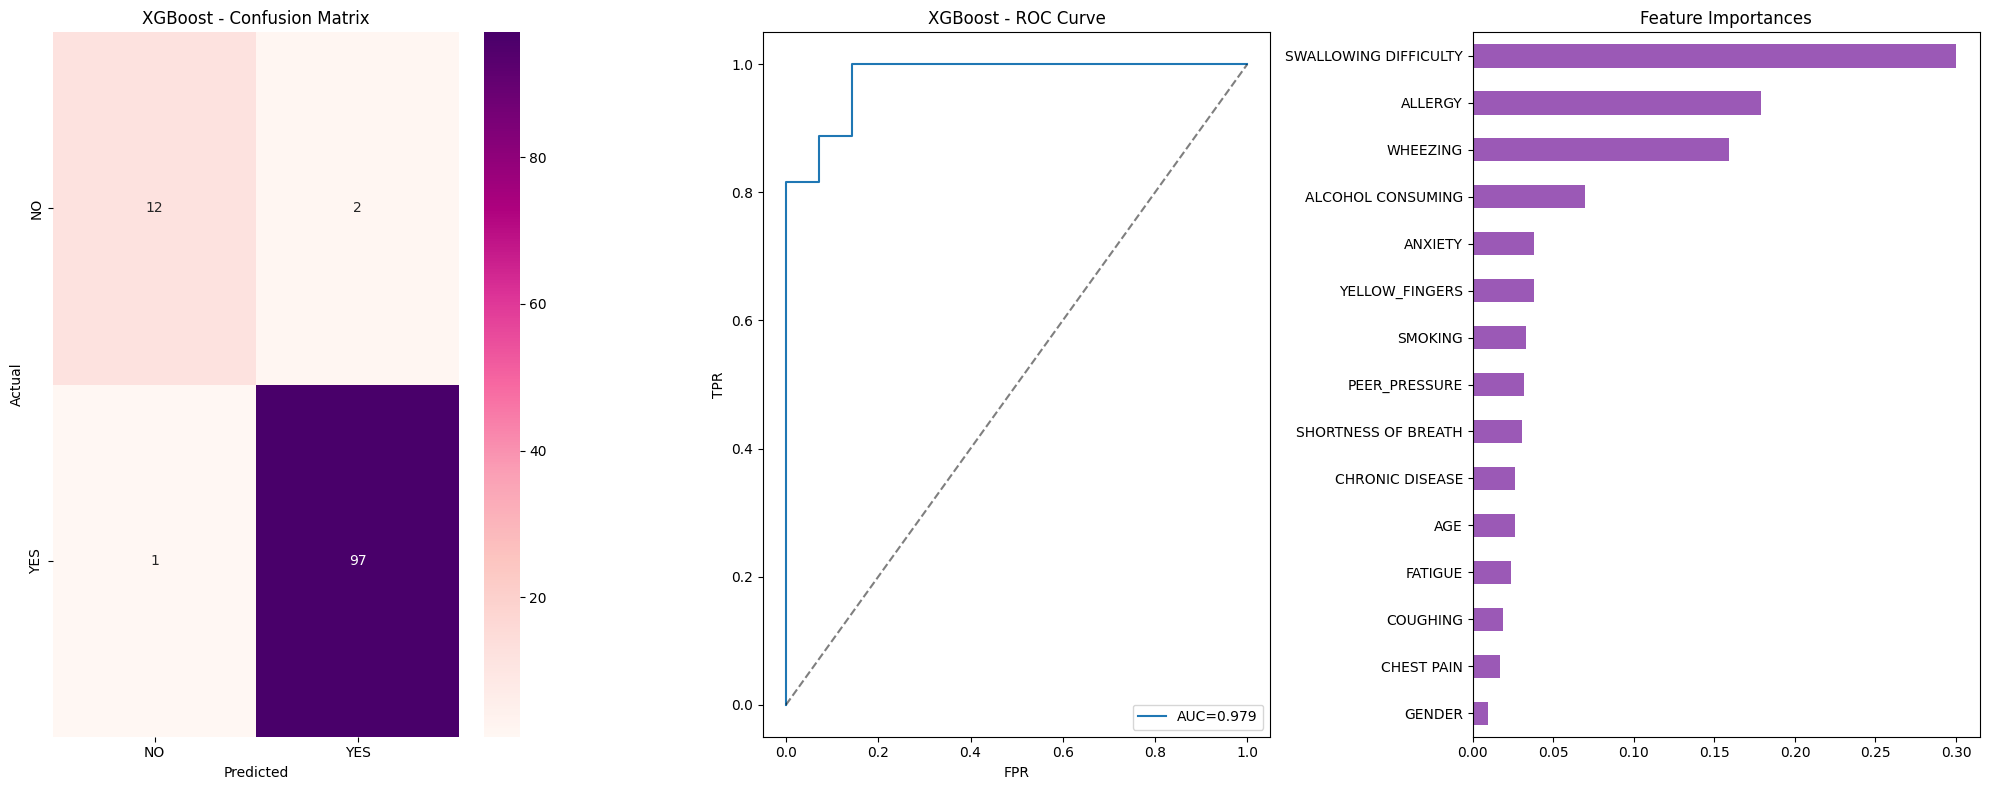

In [8]:
# Confusion Matrix, ROC, Feature Importances
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=axes[0],
            xticklabels=['NO','YES'], yticklabels=['NO','YES'])
axes[0].set_title('XGBoost - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].set_title('XGBoost - ROC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Feature Importances')

plt.tight_layout()
plt.savefig('../results/xgboost_results.png', dpi=150)
plt.show()

In [7]:
# Save model and results
MODELS_DIR = Path('..') / 'models'
joblib.dump(best_xgb, MODELS_DIR / 'xgboost.pkl')
results = pd.DataFrame([{
    'Model': 'XGBoost', 'Accuracy': acc, 'Precision': prec,
    'Recall': rec, 'F1': f1, 'AUC': auc, 'MCC': mcc
}])
results.to_csv(Path('..') / 'results' / 'xgboost_metrics.csv', index=False)
print("Model and metrics saved")

Model and metrics saved
